# Are Early Tenure Customers Quietly Costing This Company the Most?

Are new telecom customers more likely to churn? Does subscribing to more services improve customer retention?

In this project, I will use Python and Pandas to analyze customer churn, engineer meaningful features, and uncover insights that can help improve retention.

**Dataset:** Telco Customer Churn (Kaggle)

**Tools:** Python, Pandas, Matplotlib, Seaborn, SciPy


#### Step 1 : Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)

### Step 2 : Loading the data

In [3]:

df = pd.read_csv(r"E:\telco-customer-churn-analysis\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Step 3:: Initial Data Audit

In [4]:
print("Dtypes:\n", df.dtypes)
print("\nDuplicate customerIDs:", df["customerID"].duplicated().sum())
print("\nNulls per column:\n", df.isna().sum()[df.isna().sum() > 0])

blank_mask = df["TotalCharges"].astype(str).str.strip() == ""
print(f"\n{blank_mask.sum()} rows have a blank TotalCharges (new customers, tenure=0):")
df.loc[blank_mask, ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]

Dtypes:
 customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Duplicate customerIDs: 0

Nulls per column:
 Series([], dtype: int64)

11 rows have a blank TotalCharges (new customers, tenure=0):


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


### Step 4 : Clean TotalCharges and Build Churn Flag

In [5]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
assert df.loc[blank_mask, "tenure"].eq(0).all()
df["TotalCharges"] = df["TotalCharges"].fillna(0)

df["Churn_Flag"] = (df["Churn"] == "Yes").astype(int)
overall_churn = df["Churn_Flag"].mean() * 100
print(f"Overall churn rate: {overall_churn:.1f}%  ({df['Churn_Flag'].sum()} of {len(df)})")

Overall churn rate: 26.5%  (1869 of 7043)


### Step 5: Feature Engineering with Tenure Group

In [6]:
def tenure_group(months: int) -> str:
    if months <= 12:
        return "New (0-12mo)"
    elif months <= 48:
        return "Established (12-48mo)"
    else:
        return "Loyal (48mo+)"

df["Tenure_Group"] = df["tenure"].apply(tenure_group)
tenure_order = ["New (0-12mo)", "Established (12-48mo)", "Loyal (48mo+)"]
df["Tenure_Group"] = pd.Categorical(df["Tenure_Group"], categories=tenure_order, ordered=True)

df["Tenure_Group"].value_counts().reindex(tenure_order)

Tenure_Group
New (0-12mo)             2186
Established (12-48mo)    2618
Loyal (48mo+)            2239
Name: count, dtype: int64

### Step 6: Feature Enginnering with Total_Services

In [7]:
service_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
                "TechSupport", "StreamingTV", "StreamingMovies"]
df["Total_Services"] = df[service_cols].apply(lambda row: (row == "Yes").sum(), axis=1)

df["Total_Services"].value_counts().sort_index()

Total_Services
0    2219
1     966
2    1033
3    1118
4     852
5     571
6     284
Name: count, dtype: int64

### Step 7: Visualizing Churn Rate by Tenure Group

                       churn_rate  customers
Tenure_Group                                
New (0-12mo)                 47.4       2186
Established (12-48mo)        23.6       2618
Loyal (48mo+)                 9.5       2239

Chi-square p-value: 8.12e-182 (significant)


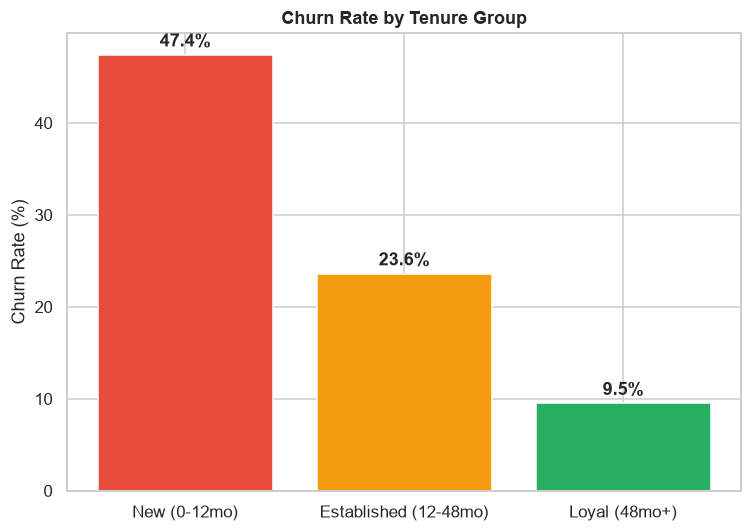

In [11]:
churn_by_tenure = (df.groupby("Tenure_Group", observed=True)["Churn_Flag"]
                      .agg(churn_rate="mean", customers="count"))
churn_by_tenure["churn_rate"] = (churn_by_tenure["churn_rate"] * 100).round(1)
print(churn_by_tenure)

ct = pd.crosstab(df["Tenure_Group"], df["Churn"])
chi2, p_tenure, dof, _ = chi2_contingency(ct)
print(f"\nChi-square p-value: {p_tenure:.2e} ({'significant' if p_tenure < 0.05 else 'not significant'})")

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(churn_by_tenure.index.astype(str), churn_by_tenure["churn_rate"],
              color=["#e74c3c", "#f39c12", "#27ae60"])
ax.bar_label(bars, fmt="%.1f%%", padding=3, fontweight="bold")
ax.set_title("Churn Rate by Tenure Group", fontweight="bold")
ax.set_ylabel("Churn Rate (%)")
plt.tight_layout()
plt.savefig(r"E:\telco-customer-churn-analysis\reports\figures\chart1_churn_by_tenure.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 8: Churn Rate by Total Services

                churn_rate  customers
Total_Services                       
0                     21.4       2219
1                     45.8        966
2                     35.8       1033
3                     27.4       1118
4                     22.3        852
5                     12.4        571
6                      5.3        284

Chi-square p-value: 2.47e-81 (significant)


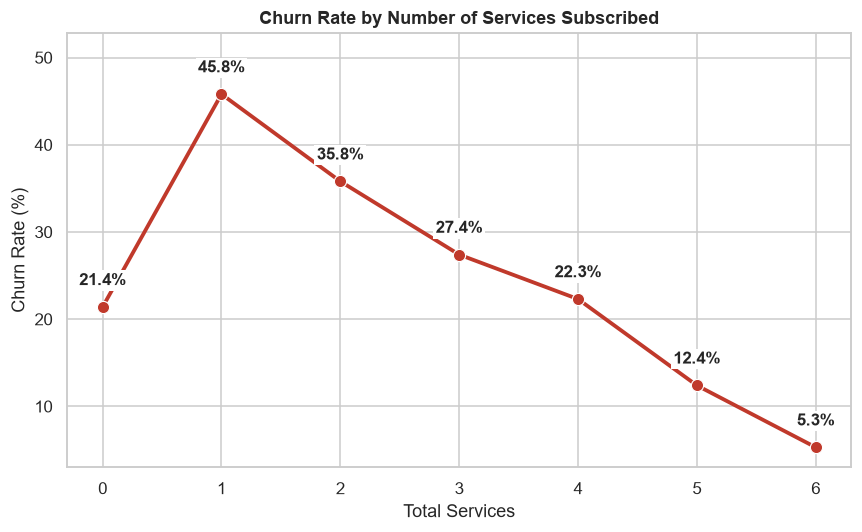

In [13]:
churn_by_services = (
    df.groupby("Total_Services")["Churn_Flag"]
      .agg(churn_rate="mean", customers="count")
)

churn_by_services["churn_rate"] = (
    churn_by_services["churn_rate"] * 100
).round(1)

print(churn_by_services)

# Chi-square test
ct2 = pd.crosstab(df["Total_Services"], df["Churn"])

chi2b, p_services, dofb, _ = chi2_contingency(ct2)

print(
    f"\nChi-square p-value: {p_services:.2e} "
    f"({'significant' if p_services < 0.05 else 'not significant'})"
)

# Ploting
fig, ax = plt.subplots(figsize=(8, 5))

sns.lineplot(
    x=churn_by_services.index,
    y=churn_by_services["churn_rate"],
    marker="o",
    linewidth=2.5,
    markersize=8,
    color="#c0392b",
    ax=ax
)

for x, y in zip(
    churn_by_services.index,
    churn_by_services["churn_rate"]
):
    ax.annotate(
        f"{y:.1f}%",
        xy=(x, y),
        xytext=(0, 12),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            pad=1.5
        )
    )

ax.set_title(
    "Churn Rate by Number of Services Subscribed",
    fontweight="bold"
)

ax.set_xlabel("Total Services")
ax.set_ylabel("Churn Rate (%)")

ax.set_ylim(
    3,
    churn_by_services["churn_rate"].max() + 7
)

plt.tight_layout()

plt.savefig(
    r"E:\telco-customer-churn-analysis\reports\figures\chart2_churn_by_services.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## Step 8: Churn Rate by Total Services

In [14]:
mystery = (df.groupby(["Contract", "Tenure_Group", "Total_Services"], observed=True)["Churn_Flag"]
             .agg(churn_rate="mean", customers="count"))
mystery["churn_rate"] = (mystery["churn_rate"] * 100).round(1)
mystery_reliable = mystery[mystery["customers"] >= 20].sort_values("churn_rate", ascending=False)
mystery_reliable.head(10)

churn_rate  customers
Contract       Tenure_Group          Total_Services                       
Month-to-month New (0-12mo)          4                     58.6         58
                                     1                     58.5        523
                                     3                     57.6        184
                                     2                     55.9        320
               Established (12-48mo) 4                     45.5        154
               New (0-12mo)          0                     43.9        895
               Established (12-48mo) 2                     39.1        389
                                     1                     37.3        319
                                     3                     36.3        339
               Loyal (48mo+)         4                     34.7         75

## Conclusion

Customer churn is highest among new customers, making early retention a clear priority. Service bundling generally reduces churn, but month-to-month contracts remain a major risk, even for established customers with multiple services.

The company should focus on early customer engagement, meaningful service bundles, and contract incentives to improve retention.


## Business Recommendations

1. **Focus on new customers.** Engage them early to reduce first-year churn.

2. **Promote service bundles.** Encourage customers to add more services to improve retention.

3. **Target month-to-month customers.** Offer contract upgrades to reduce churn among established customers.
